# Power Analysis & Design

In [1]:
import os, sys
from pathlib import Path
_cwd = Path.cwd()
_root = next((p for p in [_cwd] + list(_cwd.parents)
              if (p / 'requirements.txt').exists() and (p / 'src').is_dir()), None)
assert _root, f'Could not find project root from {_cwd}'
os.chdir(_root)
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))
print(f'Project root: {_root}')


Project root: C:\Users\markd\OneDrive\Desktop\Claude\GitHub\Projects\ab-experiment-platform


## Power Analysis & Sample-Size Design

We use the Cookie Cats 7-day baseline retention of **~0.19** (hardcoded here so this
notebook runs without external data).  We explore:

1. A sample-size table across several minimum detectable effects (MDEs).
2. A power-vs-n curve showing how achieved power grows with sample size.


In [2]:
from src.abtest import required_sample_size, power_for_sample_size

BASELINE = 0.19
MDES = [0.005, 0.01, 0.02, 0.03]

print(f"{'MDE':>6}  {'n/arm':>8}  {'total n':>9}  {'days (1k/day/arm)':>18}")
print("-" * 50)
for mde in MDES:
    res = required_sample_size(
        baseline_rate=BASELINE,
        mde_absolute=mde,
        alpha=0.05,
        power=0.80,
        daily_traffic_per_arm=1000,
    )
    print(f"{mde:>6.3f}  {res.sample_size_per_arm:>8,}  {res.total_sample_size:>9,}  {res.duration_days!r:>18}")


   MDE     n/arm    total n   days (1k/day/arm)
--------------------------------------------------
 0.005    97,601    195,202              97.601
 0.010    24,638     49,276              24.638
 0.020     6,276     12,552               6.276
 0.030     2,840      5,680                2.84


### Power-vs-n curve for MDE = 0.01


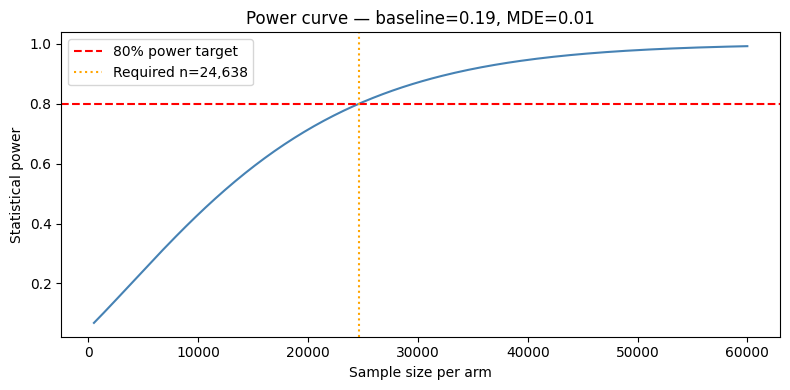

In [3]:
import numpy as np
import matplotlib.pyplot as plt

MDE = 0.01
ns = np.linspace(500, 60_000, 200).astype(int)
powers = [power_for_sample_size(baseline_rate=BASELINE, mde_absolute=MDE, n_per_arm=n) for n in ns]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ns, powers, color='steelblue')
ax.axhline(0.80, color='red', linestyle='--', label='80% power target')
required = required_sample_size(baseline_rate=BASELINE, mde_absolute=MDE, alpha=0.05, power=0.80)
ax.axvline(required.sample_size_per_arm, color='orange', linestyle=':', label=f'Required n={required.sample_size_per_arm:,}')
ax.set_xlabel('Sample size per arm')
ax.set_ylabel('Statistical power')
ax.set_title(f'Power curve — baseline={BASELINE}, MDE={MDE}')
ax.legend()
plt.tight_layout()
plt.show()


### Interpretation

- With an MDE of 0.01 (1 percentage point) on a 19% baseline, we need roughly the sample
  size shown above per arm to achieve 80% power.
- Cookie Cats collected ~44,000 users per arm — ample for MDEs ≥ 0.01.
- Smaller MDEs (0.005) require far larger samples and longer experiment durations.
